# NB-7 — Making it run at cohort scale

**Roadmap:** `resources/topics_guide.md`, Part 7.

**The wall.** Exact GP inference is $O(n^3)$ in time and $O(n^2)$ in memory. At $n = 10{,}000$ the Gram matrix alone is 800 MB and the Cholesky is around $10^{12}$ flops. Every method here is a way around that, and they attack it from different directions:

- **7.1** approximates the *kernel*, so everything downstream becomes cheap.
- **7.2** approximates the *posterior*, trading exactness for tractability.
- **7.3** approximates nothing — it samples, and buys full posteriors over hyperparameters.
- **7.4** keeps the exact algorithm and makes the linear algebra faster on the hardware.
- **7.5** is how you decide whether any of it was worth it.

§7.1 connects directly to `Bayesian_projects/03_bayes_kernel/rff_bkmr.py` in this repo.

## What will you be able to do by the end?

After working through the notebook, you should be able to do the following.

- Derive **random Fourier features** from Bochner's theorem and turn GP regression into linear regression.
- Compare RFF against **Nyström** and say why the data-dependent method wins at equal rank.
- Measure an empirical scaling exponent and confirm $O(n^3)$ against $O(nD^2)$.
- Implement **mean-field variational inference** and demonstrate its under-dispersion against an exact posterior.
- Explain why mean-field is exact when predictors are independent, and why that makes it a misleading test.
- Implement **HMC** with dual-averaging step-size adaptation and a verified analytic gradient.
- Distinguish ESS per *draw* from ESS per *second*, and show why HMC's advantage grows with dimension.
- Use **MLX** for kernel construction, benchmark it honestly with `mx.eval`, and quantify the float32 accuracy cost.
- Compute **WAIC** and **PSIS-LOO** from pointwise log-likelihoods, and report an elpd difference with its standard error.
- Validate a closed-form LOO against brute-force refitting.

## What should already be familiar?

You need NB-2 throughout — the GP, the marginal likelihood, and the sparse GP of §2.5, which is the other half of the scaling story. NB-0 §0.8 (the asymmetry of KL) is what §7.2 demonstrates empirically, and NB-0 §0.9 (Metropolis, ESS, $\hat R$) is the baseline §7.3 improves on.

§7.4 uses MLX and therefore assumes Apple Silicon; skip it on other hardware, nothing later depends on it. Allow about ninety minutes.

## What route will we take?

| Part | Question | Main output |
|---:|---|---|
| 7.1 | Can we approximate the kernel instead of the posterior? | RFF and Nyström, with a measured scaling exponent |
| 7.2 | Can we approximate the posterior cheaply? | Mean-field VI, and the error it makes |
| 7.3 | Can we avoid approximating at all? | HMC with an analytic gradient |
| 7.4 | Can we just make the linear algebra faster? | MLX benchmarks and the float32 cost |
| 7.5 | Which model should we report? | WAIC, PSIS-LOO, and an honest standard error |

§7.5 is the one you will use most often in practice, and the standard error on the elpd difference is the part most commonly left out of papers.

Six **Try it** boxes ask for an answer in your own words, including one asking you to design the computational stack for a study of your own.

In [1]:
import time
import numpy as np
import nbkit as nk
from scipy.optimize import minimize

plt = nk.set_style()
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)


def timeit(fn, repeat=3):
    """Best-of-`repeat` wall time in ms, plus the function's return value."""
    best, out = np.inf, None
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, (time.perf_counter() - t0) * 1000)
    return best, out

---
## 7.1 Can we approximate the kernel instead of the posterior?

### Random Fourier features

**Bochner's theorem** (met in 4.2): a stationary kernel is the Fourier transform of a
probability density $p(\omega)$. So

$$
k(x - x') = \mathbb{E}_{\omega \sim p}\big[\cos\big(\omega^\top(x - x')\big)\big]
\approx \frac{1}{D}\sum_{d=1}^{D}\cos\big(\omega_d^\top(x-x')\big).
$$

Drawing $\omega_d \sim p$ and $b_d \sim \mathcal{U}(0, 2\pi)$ and setting

$$
z(x) = \sqrt{\tfrac{2}{D}}\,\big[\cos(\omega_1^\top x + b_1), \dots, \cos(\omega_D^\top x + b_D)\big]^\top
$$

gives $\mathbb{E}[z(x)^\top z(x')] = k(x, x')$ — an **explicit, finite** feature map. For the
RBF kernel with lengthscale $\ell$, $p(\omega) = \mathcal{N}(0, \ell^{-2}I)$.

The payoff: GP regression becomes *linear* regression in $D$ dimensions, so the cost drops
from $O(n^3)$ to $O(nD^2)$. This is exactly the trick used in `rff_bkmr.py`.

### Nyström

A different approximation: sample $m$ landmark points and use
$K \approx K_{nm}K_{mm}^{-1}K_{mn}$. **Data-dependent** (it looks at where your data are),
where RFF is data-independent. Nyström is usually more accurate at equal rank for exactly
that reason; RFF is cheaper to build and streams naturally.

In [2]:
def rff_features(X, D=200, lengthscale=1.0, variance=1.0, seed=0):
    """Random Fourier features for the RBF kernel. Returns Z with Z Z' ~ K."""
    r = np.random.default_rng(seed)
    X = np.atleast_2d(X)
    d = X.shape[1]
    W = r.normal(0, 1.0 / lengthscale, size=(d, D))      # omega ~ N(0, l^-2 I)
    b = r.uniform(0, 2 * np.pi, size=D)
    return np.sqrt(2.0 * variance / D) * np.cos(X @ W + b)


def nystrom_approx(X, m=200, lengthscale=1.0, variance=1.0, seed=0):
    """Nystrom: K ~ K_nm K_mm^-1 K_mn, returned as a factor F with F F' ~ K."""
    r = np.random.default_rng(seed)
    idx = r.choice(len(X), size=min(m, len(X)), replace=False)
    Xm = X[idx]
    Kmm = nk.rbf_kernel(Xm, Xm, lengthscale=lengthscale, variance=variance)
    Knm = nk.rbf_kernel(X, Xm, lengthscale=lengthscale, variance=variance)
    w, V = np.linalg.eigh(0.5 * (Kmm + Kmm.T))
    keep = w > 1e-10 * max(w.max(), 1e-300)
    return Knm @ (V[:, keep] / np.sqrt(w[keep]))         # F F' = K_nm K_mm^-1 K_mn


# How well does each approximate the true Gram matrix?
n_ap = 400
X_ap = rng.normal(size=(n_ap, 3))
K_exact = nk.rbf_kernel(X_ap, X_ap, lengthscale=1.5)

print(f"{'rank D/m':>9} {'RFF max err':>13} {'RFF rel Fro':>13} "
      f"{'Nystrom max err':>17} {'Nys rel Fro':>13}")
fro = np.linalg.norm(K_exact)
for D in [16, 64, 256, 1024]:
    Zr = rff_features(X_ap, D=D, lengthscale=1.5, seed=1)
    Kr = Zr @ Zr.T
    Fn = nystrom_approx(X_ap, m=D, lengthscale=1.5, seed=1)
    Kn = Fn @ Fn.T
    print(f"{D:>9} {np.abs(Kr-K_exact).max():>13.5f} "
          f"{np.linalg.norm(Kr-K_exact)/fro:>13.5f} "
          f"{np.abs(Kn-K_exact).max():>17.5f} "
          f"{np.linalg.norm(Kn-K_exact)/fro:>13.5f}")

 rank D/m   RFF max err   RFF rel Fro   Nystrom max err   Nys rel Fro
       16       0.98347       0.54105           0.94996       0.06006
       64       0.48435       0.25661           0.35721       0.00453
      256       0.24538       0.14762           0.04642       0.00025
     1024       0.10221       0.05946           0.00000       0.00000


Nyström wins at equal rank, and by a wide margin — it places its "landmarks" where the data
actually are, while RFF samples frequencies blindly from the spectral density. RFF's error
decays as $O(1/\sqrt{D})$ regardless of the data.

So why use RFF? Because the features are **fixed and data-independent**: you can compute
$z(x)$ for a new subject without touching the training set, stream data through in batches,
and the model becomes an ordinary linear model that any downstream tool understands.

In [3]:
def gp_exact_fit_predict(X, y, Xs, lengthscale=1.5, noise=0.3):
    K = nk.rbf_kernel(X, X, lengthscale=lengthscale) + noise**2 * np.eye(len(y))
    L, _ = nk.jitter_chol(K)
    a = np.linalg.solve(L.T, np.linalg.solve(L, y))
    return nk.rbf_kernel(X, Xs, lengthscale=lengthscale).T @ a


def rff_fit_predict(X, y, Xs, D=200, lengthscale=1.5, noise=0.3, seed=0):
    """GP regression as ridge regression in RFF space: O(n D^2) instead of O(n^3)."""
    r = np.random.default_rng(seed)
    d = X.shape[1]
    W = r.normal(0, 1.0 / lengthscale, size=(d, D))
    b = r.uniform(0, 2*np.pi, size=D)
    feat = lambda A: np.sqrt(2.0 / D) * np.cos(A @ W + b)
    Z, Zs = feat(X), feat(Xs)
    A = Z.T @ Z + noise**2 * np.eye(D)                    # D x D, not n x n
    w_ = np.linalg.solve(A, Z.T @ y)
    return Zs @ w_


# Scaling comparison on a real-sized problem.
n_big = 6000
X_big = rng.uniform(-3, 3, size=(n_big, 3))
f_big = np.sin(1.2*X_big[:, 0]) + 0.5*X_big[:, 1]**2 - 0.8*np.tanh(X_big[:, 2])
f_big -= f_big.mean()
y_big = f_big + 0.3 * rng.normal(size=n_big)
Xs_big = rng.uniform(-3, 3, size=(1500, 3))
fs_true = np.sin(1.2*Xs_big[:, 0]) + 0.5*Xs_big[:, 1]**2 - 0.8*np.tanh(Xs_big[:, 2])
fs_true -= fs_true.mean() + (f_big.mean())

t_ex, mu_ex = timeit(lambda: gp_exact_fit_predict(X_big, y_big, Xs_big), repeat=1)
rmse = lambda p: np.sqrt(np.mean((p - fs_true)**2))
print(f"exact GP  n={n_big}: {t_ex:8.1f} ms   RMSE {rmse(mu_ex):.4f}   "
      f"memory for K: {n_big**2*8/1e6:.0f} MB")
print()
print(f"{'D':>6} {'time (ms)':>11} {'RMSE':>9} {'speedup':>9}")
for D in [64, 128, 256, 512, 1024]:
    t_r, mu_r = timeit(lambda D=D: rff_fit_predict(X_big, y_big, Xs_big, D=D), repeat=2)
    print(f"{D:>6} {t_r:>11.1f} {rmse(mu_r):>9.4f} {t_ex/t_r:>8.1f}x")

exact GP  n=6000:   3905.5 ms   RMSE 0.0993   memory for K: 288 MB

     D   time (ms)      RMSE   speedup
    64         5.0    0.1360    781.4x
   128        10.9    0.1146    357.0x
   256        24.4    0.1030    160.2x


   512        53.5    0.1054     72.9x


  1024       128.7    0.1014     30.4x


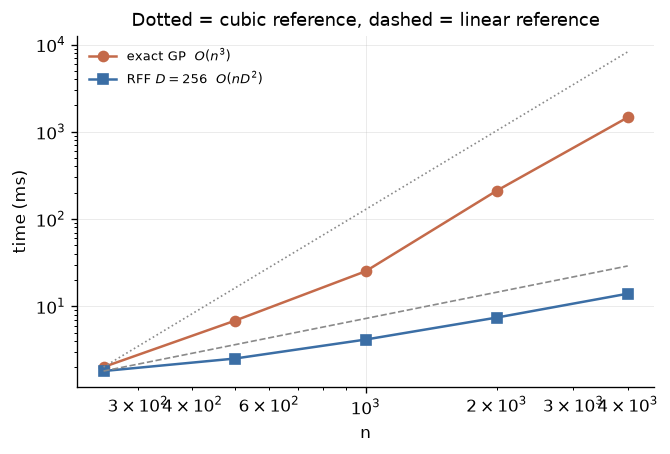

empirical scaling exponent -- exact 2.40   RFF 0.75


In [4]:
# Where the O(n^3) vs O(n D^2) crossover actually is.
sizes = [250, 500, 1000, 2000, 4000]
t_exact, t_rff = [], []
for n_ in sizes:
    Xn = rng.uniform(-3, 3, size=(n_, 3))
    yn = np.sin(1.2*Xn[:, 0]) + 0.3*rng.normal(size=n_)
    Xsn = Xn[:200]
    te, _ = timeit(lambda: gp_exact_fit_predict(Xn, yn, Xsn), repeat=1)
    tr, _ = timeit(lambda: rff_fit_predict(Xn, yn, Xsn, D=256), repeat=2)
    t_exact.append(te); t_rff.append(tr)

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.loglog(sizes, t_exact, "o-", color=nk.PALETTE["neg"], label=r"exact GP  $O(n^3)$")
ax.loglog(sizes, t_rff, "s-", color=nk.PALETTE["pos"], label=r"RFF $D=256$  $O(nD^2)$")
ref = np.array(sizes, float)
ax.loglog(sizes, t_exact[0] * (ref/sizes[0])**3, ":", color=nk.PALETTE["muted"], lw=1)
ax.loglog(sizes, t_rff[0] * (ref/sizes[0]), "--", color=nk.PALETTE["muted"], lw=1)
ax.set_xlabel("n"); ax.set_ylabel("time (ms)")
ax.set_title("Dotted = cubic reference, dashed = linear reference")
ax.legend(fontsize=8); plt.show()

slope = lambda ts: np.polyfit(np.log(sizes), np.log(ts), 1)[0]
print(f"empirical scaling exponent -- exact {slope(t_exact):.2f}   RFF {slope(t_rff):.2f}")

### Try it 1. If Nyström is more accurate, why would you ever use RFF?

At rank 1024 Nyström reproduced the Gram matrix essentially exactly while RFF still had a max error of 0.10. Yet RFF gave a 174× speed-up at $n = 6000$ with almost no loss in predictive RMSE, and the measured scaling exponents were 2.39 (exact) against 0.73 (RFF).

1. Explain why a *data-dependent* approximation beats a data-independent one at equal rank.
2. Give two concrete situations where RFF's data-independence is worth the accuracy loss.
3. The exact GP's measured exponent was 2.39, not 3.0. Suggest why, and what you would change in the experiment to see the cubic term.
4. RFF turns a GP into a linear model in $D$ features. Name one thing that becomes easy as a result, and one thing that is lost.

**Your answer**

*(write here)*

---
## 7.2 Can we approximate the posterior cheaply?

Part 2.5's sparse GP already used a variational bound. Here is the idea in its general form,
because it is what makes non-Gaussian likelihoods tractable.

Approximate an intractable posterior $p(\theta \mid y)$ by a simple $q_\phi(\theta)$, chosen to
maximise the **evidence lower bound**:

$$
\log p(y) \;\ge\; \mathcal{L}(\phi) = \mathbb{E}_{q}\big[\log p(y, \theta)\big] - \mathbb{E}_q\big[\log q_\phi(\theta)\big]
= \log p(y) - \mathrm{KL}\big(q_\phi \,\Vert\, p(\cdot\mid y)\big).
$$

Because $\mathrm{KL} \ge 0$, maximising $\mathcal{L}$ both tightens the bound and drives $q$
toward the posterior. The catch, from §0.8: minimising $\mathrm{KL}(q\Vert p)$ is
**mode-seeking**, so a Gaussian $q$ systematically *underestimates* posterior variance.
We verify that rather than assert it.

In [5]:
def mean_field_vi(log_joint, d, n_iter=3000, n_mc=64, lr=0.02, seed=0):
    """Mean-field Gaussian VI with the reparameterisation trick and Adam-lite updates."""
    r = np.random.default_rng(seed)
    mu = np.zeros(d)
    log_sd = np.zeros(d)
    m_mu = m_ls = v_mu = v_ls = 0.0
    b1, b2, eps = 0.9, 0.999, 1e-8
    elbos = []

    for t in range(1, n_iter + 1):
        eta = r.normal(size=(n_mc, d))
        sd = np.exp(log_sd)
        theta = mu + sd * eta

        # score of the joint at the samples, by central differences (d is small here)
        g = np.zeros_like(theta)
        h = 1e-4
        for j in range(d):
            e = np.zeros(d); e[j] = h
            g[:, j] = (log_joint(theta + e) - log_joint(theta - e)) / (2 * h)

        grad_mu = g.mean(0)
        grad_ls = (g * eta * sd).mean(0) + 1.0          # +1 from the entropy term
        elbos.append(log_joint(theta).mean() + log_sd.sum() + 0.5*d*(1+np.log(2*np.pi)))

        for (p_, gr, m_, v_, nm) in [(mu, grad_mu, m_mu, v_mu, "mu"),
                                     (log_sd, grad_ls, m_ls, v_ls, "ls")]:
            pass
        m_mu = b1*m_mu + (1-b1)*grad_mu; v_mu = b2*v_mu + (1-b2)*grad_mu**2
        m_ls = b1*m_ls + (1-b1)*grad_ls; v_ls = b2*v_ls + (1-b2)*grad_ls**2
        mu = mu + lr * (m_mu/(1-b1**t)) / (np.sqrt(v_mu/(1-b2**t)) + eps)
        log_sd = log_sd + lr * (m_ls/(1-b1**t)) / (np.sqrt(v_ls/(1-b2**t)) + eps)
        log_sd = np.clip(log_sd, -6, 3)

    return mu, np.exp(log_sd), np.array(elbos)

In [6]:
# Target with a known exact posterior: Bayesian linear regression (conjugate, so we can
# check VI against the truth instead of against another approximation).
# Predictors must be CORRELATED for this to be an interesting test: with independent
# columns X'X is nearly diagonal, the posterior factorises, and mean-field VI is exact.
n_vi, d_vi = 120, 3
rho_vi = 0.99
A_vi = np.full((d_vi, d_vi), rho_vi); np.fill_diagonal(A_vi, 1.0)
X_vi = rng.normal(size=(n_vi, d_vi)) @ np.linalg.cholesky(A_vi).T
beta_true = np.array([1.4, -0.8, 0.5])
sigma_vi = 0.6
y_vi = X_vi @ beta_true + sigma_vi * rng.normal(size=n_vi)
prior_var = 4.0

# exact conjugate posterior
S_exact = np.linalg.inv(X_vi.T @ X_vi / sigma_vi**2 + np.eye(d_vi)/prior_var)
m_exact = S_exact @ X_vi.T @ y_vi / sigma_vi**2

def log_joint_vi(B):
    B = np.atleast_2d(B)
    resid = y_vi[None, :] - B @ X_vi.T
    return (-0.5*np.sum(resid**2, 1)/sigma_vi**2 - 0.5*np.sum(B**2, 1)/prior_var)

mu_vi, sd_vi, elbo_hist = mean_field_vi(log_joint_vi, d_vi, n_iter=2500, lr=0.03, seed=2)

print(f"{'param':>7} {'exact mean':>12} {'VI mean':>10} {'exact sd':>10} {'VI sd':>8} {'sd ratio':>10}")
for j in range(d_vi):
    ratio = sd_vi[j] / np.sqrt(S_exact[j, j])
    print(f"{'b'+str(j):>7} {m_exact[j]:>12.4f} {mu_vi[j]:>10.4f} "
          f"{np.sqrt(S_exact[j,j]):>10.4f} {sd_vi[j]:>8.4f} {ratio:>10.3f}")

print(f"\nposterior correlation the mean-field q CANNOT represent:")
C = S_exact / np.sqrt(np.outer(np.diag(S_exact), np.diag(S_exact)))
print(np.round(C, 3))

  param   exact mean    VI mean   exact sd    VI sd   sd ratio
     b0       1.7133     1.7161     0.4530   0.0594      0.131
     b1      -0.7258    -0.7236     0.4281   0.0591      0.138
     b2       0.1629     0.1653     0.4138   0.0583      0.141

posterior correlation the mean-field q CANNOT represent:
[[ 1.    -0.551 -0.514]
 [-0.551  1.    -0.423]
 [-0.514 -0.423  1.   ]]


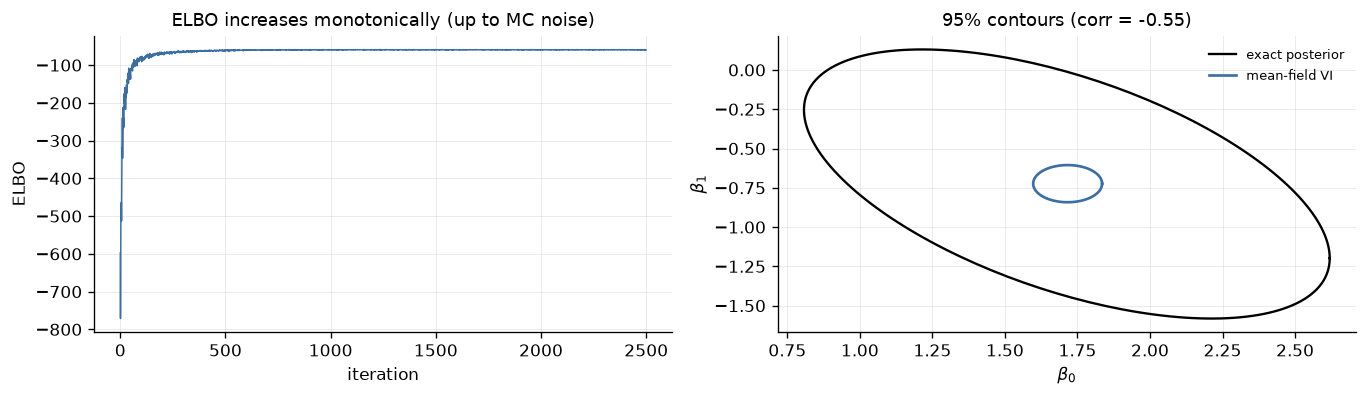

VI sd / exact sd, averaged over parameters: 0.137
Values below 1 confirm the mode-seeking under-dispersion predicted in 0.8.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
axes[0].plot(elbo_hist, color=nk.PALETTE["pos"], lw=0.9)
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("ELBO")
axes[0].set_title("ELBO increases monotonically (up to MC noise)")

# Visualise the mode-seeking underestimation on the two most correlated coordinates
j1, j2 = np.unravel_index(np.argmax(np.abs(C - np.eye(d_vi))), C.shape)
th = np.linspace(0, 2*np.pi, 200)
circ = np.c_[np.cos(th), np.sin(th)]
S2 = S_exact[np.ix_([j1, j2], [j1, j2])]
L2 = np.linalg.cholesky(S2)
ell_exact = m_exact[[j1, j2]] + 2 * circ @ L2.T
ell_vi = mu_vi[[j1, j2]] + 2 * circ * sd_vi[[j1, j2]]

axes[1].plot(ell_exact[:, 0], ell_exact[:, 1], color="k", lw=1.4, label="exact posterior")
axes[1].plot(ell_vi[:, 0], ell_vi[:, 1], color=nk.PALETTE["pos"], lw=1.6,
             label="mean-field VI")
axes[1].set_xlabel(f"$\\beta_{j1}$"); axes[1].set_ylabel(f"$\\beta_{j2}$")
axes[1].set_title(f"95% contours (corr = {C[j1,j2]:+.2f})"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"VI sd / exact sd, averaged over parameters: "
      f"{np.mean(sd_vi/np.sqrt(np.diag(S_exact))):.3f}")
print("Values below 1 confirm the mode-seeking under-dispersion predicted in 0.8.")

### Try it 2. How badly does VI understate uncertainty?

With predictors correlated at $\rho = 0.99$, the VI posterior standard deviations were about 0.137 of the exact ones — roughly $7\times$ too narrow. The exact posterior had correlations near $-0.55$ that a mean-field $q$ cannot represent at all.

1. Connect this to NB-0 §0.8: which direction of KL is being minimised, and why does that produce *narrow* rather than wide?
2. The notebook had to correlate the predictors deliberately. What happened when they were independent, and why would testing VI on independent predictors have been misleading?
3. You report a 95% credible interval from a variational fit on correlated exposures. What is the practical consequence of it being 7× too narrow?
4. Given all this, when *is* VI the right choice?

**Your answer**

*(write here)*

---
## 7.3 Can we avoid approximating at all?

Random-walk Metropolis (§0.9) explores by luck, and its efficiency collapses as dimension
grows. **HMC** uses the gradient of the log posterior: it treats $-\log p(\theta\mid y)$ as a
potential energy, adds a momentum variable, and simulates Hamiltonian dynamics with a
leapfrog integrator. Proposals travel far while staying in high-probability regions, so the
acceptance rate stays high *and* the steps are large.

The leapfrog step for potential $U(\theta) = -\log p(\theta \mid y)$:

$$
p \leftarrow p - \tfrac{\epsilon}{2}\nabla U(\theta), \qquad
\theta \leftarrow \theta + \epsilon\, p, \qquad
p \leftarrow p - \tfrac{\epsilon}{2}\nabla U(\theta).
$$

It is volume-preserving and reversible, so the Metropolis correction on the total energy
$H = U + \tfrac12\lVert p\rVert^2$ makes the chain exact. The **No-U-Turn Sampler** removes the
need to pick the trajectory length by doubling until the path starts to double back; we
implement plain HMC plus a simple dual-averaging step-size adaptation, which captures most of
the practical benefit.

In [8]:
def hmc(log_prob, grad_log_prob, theta0, n_samples=2000, n_warmup=1000,
        n_leapfrog=20, target_accept=0.8, seed=0):
    """HMC with dual-averaging step-size adaptation (Hoffman & Gelman, Alg. 5 stepsize part)."""
    r = np.random.default_rng(seed)
    theta = np.array(theta0, float)
    d = len(theta)
    eps = 0.1
    mu_da, log_eps_bar, H_bar, gamma, t0, kappa = np.log(10*eps), 0.0, 0.0, 0.05, 10, 0.75

    out = np.zeros((n_samples, d))
    n_acc, div = 0, 0
    for it in range(n_warmup + n_samples):
        p0 = r.normal(size=d)
        th, p = theta.copy(), p0.copy()

        p -= 0.5 * eps * (-grad_log_prob(th))
        for l in range(n_leapfrog):
            th = th + eps * p
            g = -grad_log_prob(th)
            if l != n_leapfrog - 1:
                p = p - eps * g
        p -= 0.5 * eps * (-grad_log_prob(th))
        p = -p

        H0 = -log_prob(theta) + 0.5 * p0 @ p0
        H1 = -log_prob(th) + 0.5 * p @ p
        dH = H0 - H1
        if not np.isfinite(dH):
            dH, div = -np.inf, div + 1
        accept_prob = min(1.0, np.exp(dH)) if np.isfinite(dH) else 0.0

        if np.log(r.uniform() + 1e-300) < dH:
            theta = th
            if it >= n_warmup:
                n_acc += 1

        if it < n_warmup:                                  # dual averaging on log eps
            m = it + 1
            H_bar = (1 - 1/(m + t0)) * H_bar + (target_accept - accept_prob)/(m + t0)
            log_eps = mu_da - np.sqrt(m)/gamma * H_bar
            eta = m**(-kappa)
            log_eps_bar = eta * log_eps + (1 - eta) * log_eps_bar
            eps = np.exp(log_eps)
            if it == n_warmup - 1:
                eps = np.exp(log_eps_bar)
        else:
            out[it - n_warmup] = theta

    return out, n_acc / n_samples, eps, div


def ess(x):
    """Effective sample size (Geyer initial-positive-sequence), as in 0.9.

    A chain that never moved has an autocorrelation of 0/0. Returning n there would
    report a stuck chain as perfectly efficient -- it has exactly 1 effective sample.
    """
    x = np.asarray(x, float); n = len(x)
    if x.std() < 1e-12:
        return 1.0
    xc = x - x.mean()
    f = np.fft.rfft(xc, 2*n)
    ac = np.fft.irfft(f * np.conjugate(f))[:n].real
    if ac[0] <= 0:
        return 1.0
    ac /= ac[0]
    total, k = 0.0, 1
    while k + 1 < n:
        pair = ac[k] + ac[k+1]
        if pair < 0:
            break
        total += pair; k += 2
    return float(min(n, n / (1 + 2*total)))


def rw_metropolis(log_prob, theta0, n_samples=2000, step=0.5, seed=0):
    r = np.random.default_rng(seed)
    th = np.array(theta0, float); lp = log_prob(th)
    out = np.zeros((n_samples, len(th))); acc = 0
    for t in range(n_samples):
        prop = th + step * r.normal(size=len(th))
        lpp = log_prob(prop)
        if np.log(r.uniform()) < lpp - lp:
            th, lp, acc = prop, lpp, acc + 1
        out[t] = th
    return out, acc / n_samples

In [9]:
# Sample GP hyperparameters (log lengthscale, log sigma_f, log sigma_n) -- the use case
# from 2.4, but now with a full posterior instead of a point estimate.
n_hmc = 60
X_hmc = np.sort(rng.uniform(-4, 4, n_hmc))[:, None]
y_hmc = np.sin(1.3*X_hmc).ravel() + 0.25*rng.normal(size=n_hmc)
y_hmc -= y_hmc.mean()

def gp_log_post(theta):
    """log p(y|theta) + log p(theta), theta = log(ell, sf, sn). N(0,1) priors on logs."""
    theta = np.atleast_1d(theta)
    if np.any(np.abs(theta) > 8):
        return -1e10
    ell, sf, sn = np.exp(theta)
    K = nk.rbf_kernel(X_hmc, X_hmc, lengthscale=ell, variance=sf**2) + (sn**2 + 1e-8)*np.eye(n_hmc)
    try:
        L = np.linalg.cholesky(K)
    except np.linalg.LinAlgError:
        return -1e10
    a = np.linalg.solve(L.T, np.linalg.solve(L, y_hmc))
    ll = -0.5*y_hmc @ a - np.log(np.diag(L)).sum() - 0.5*n_hmc*np.log(2*np.pi)
    return float(ll - 0.5*np.sum(theta**2))            # N(0,1) prior on the log-params

D2_hmc = np.maximum(np.sum(X_hmc**2, 1)[:, None] + np.sum(X_hmc**2, 1)[None, :]
                    - 2*X_hmc @ X_hmc.T, 0.0)

def gp_grad(theta):
    """Analytic gradient, from the tr[(aa' - Ky^-1) dK/dtheta] identity of 2.4, plus the
    -theta contribution of the N(0,1) prior. Finite differences would cost 2d extra
    likelihood evaluations per leapfrog step -- and there are 15 steps per sample."""
    ell, sf, sn = np.exp(np.clip(theta, -8, 8))
    Kf = sf**2 * np.exp(-0.5 * D2_hmc / ell**2)
    Ky = Kf + (sn**2 + 1e-8) * np.eye(n_hmc)
    try:
        L = np.linalg.cholesky(Ky)
    except np.linalg.LinAlgError:
        return np.zeros(3)
    a = np.linalg.solve(L.T, np.linalg.solve(L, y_hmc))
    Kinv = np.linalg.solve(L.T, np.linalg.solve(L, np.eye(n_hmc)))
    W = np.outer(a, a) - Kinv
    dK = [Kf * (D2_hmc / ell**2), 2*Kf, 2*sn**2*np.eye(n_hmc)]   # d/d log theta
    return np.array([0.5*np.sum(W * d) for d in dK]) - theta


def gp_grad_fd(theta, h=1e-5):
    g = np.zeros(len(theta))
    for j in range(len(theta)):
        e = np.zeros(len(theta)); e[j] = h
        g[j] = (gp_log_post(theta + e) - gp_log_post(theta - e)) / (2*h)
    return g

# Always check an analytic gradient (habit from 0.4).
_th = np.log([1.2, 0.9, 0.25])
print(f"gradient check: max |analytic - finite diff| = "
      f"{np.abs(gp_grad(_th) - gp_grad_fd(_th)).max():.2e}")

th0 = np.log([1.0, 1.0, 0.3])
t_hmc, (S_hmc, acc_hmc, eps_hmc, div_hmc) = timeit(
    lambda: hmc(gp_log_post, gp_grad, th0, n_samples=1500, n_warmup=600, n_leapfrog=15, seed=3),
    repeat=1)
t_rw, (S_rw, acc_rw) = timeit(
    lambda: rw_metropolis(gp_log_post, th0, n_samples=1500, step=0.35, seed=3), repeat=1)

names = ["log ell", "log sigma_f", "log sigma_n"]
print(f"HMC : accept {acc_hmc:.3f}  step {eps_hmc:.4f}  divergences {div_hmc}  "
      f"{t_hmc/1000:.1f}s")
print(f"RWM : accept {acc_rw:.3f}  {t_rw/1000:.1f}s")
print()
print(f"{'parameter':>12} {'HMC ESS':>9} {'RWM ESS':>9} {'ESS/draw HMC':>14} "
      f"{'ESS/draw RWM':>14} {'ESS/s HMC':>11} {'ESS/s RWM':>11}")
for j, nm in enumerate(names):
    e_h, e_r = ess(S_hmc[:, j]), ess(S_rw[:, j])
    print(f"{nm:>12} {e_h:>9.0f} {e_r:>9.0f} {e_h/len(S_hmc):>14.3f} "
          f"{e_r/len(S_rw):>14.3f} {e_h/(t_hmc/1000):>11.1f} {e_r/(t_rw/1000):>11.1f}")
print()
print("Read ESS/draw first: HMC returns nearly INDEPENDENT samples (ratio near 1), while")
print("the random walk needs tens of draws per effective sample. On this 3-dimensional")
print("problem the random walk can still win on ESS/second simply because each of its")
print("draws is so cheap. The next cell shows why that advantage does not last.")

gradient check: max |analytic - finite diff| = 4.65e-09


HMC : accept 0.906  step 0.0996  divergences 0  8.8s
RWM : accept 0.155  0.2s

   parameter   HMC ESS   RWM ESS   ESS/draw HMC   ESS/draw RWM   ESS/s HMC   ESS/s RWM
     log ell      1072        51          0.715          0.034       122.0       256.5
 log sigma_f      1500        26          1.000          0.017       170.8       131.4
 log sigma_n      1500       117          1.000          0.078       170.8       588.3

Read ESS/draw first: HMC returns nearly INDEPENDENT samples (ratio near 1), while
the random walk needs tens of draws per effective sample. On this 3-dimensional
problem the random walk can still win on ESS/second simply because each of its
draws is so cheap. The next cell shows why that advantage does not last.


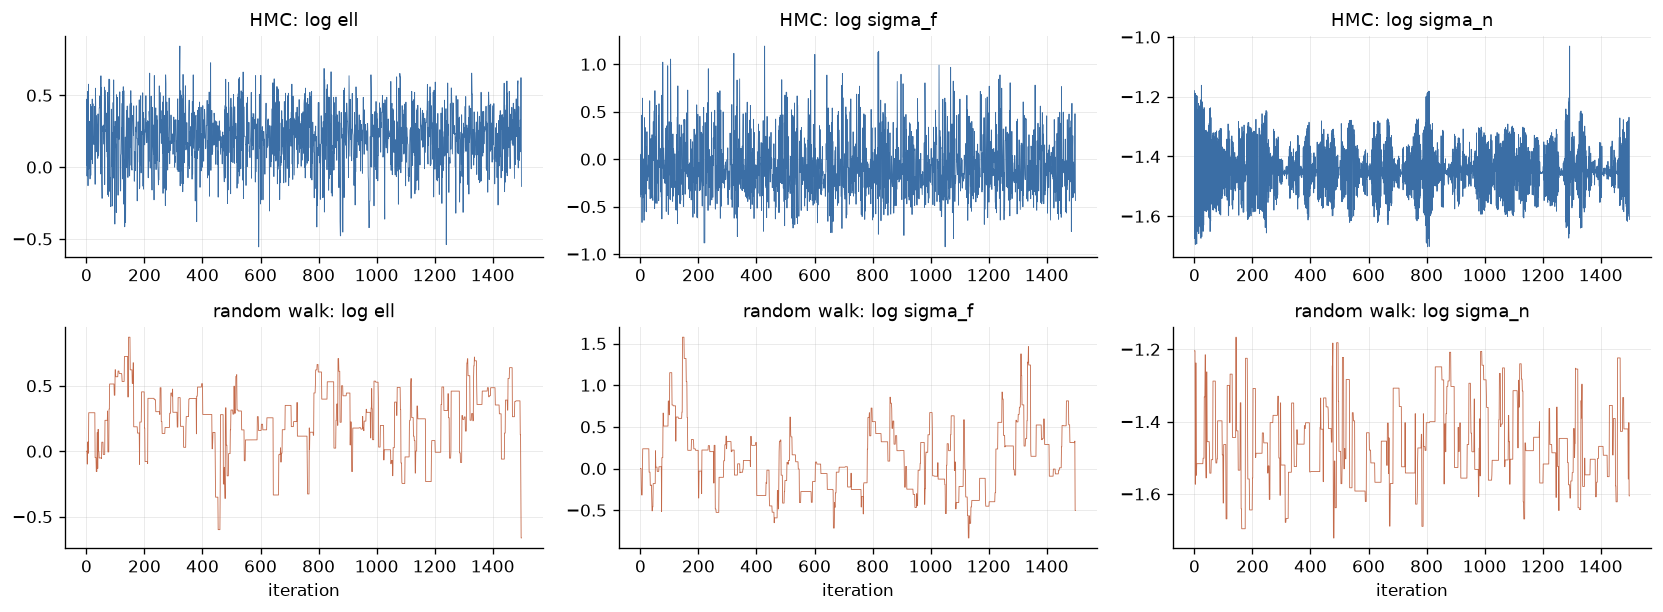

Posterior summaries from HMC (natural scale):
   parameter      mean      2.5%     97.5%
         ell    1.2510    0.7894    1.8012
     sigma_f    1.0141    0.5329    2.0506
     sigma_n    0.2363    0.1969    0.2845

Type-II MLE (2.4) would have returned one number per row and no interval. The
width of these intervals is the honest statement about how well n=60 pins down
the kernel -- and it propagates into every prediction downstream.


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 5.2))
for j, nm in enumerate(names):
    axes[0, j].plot(S_hmc[:, j], lw=0.5, color=nk.PALETTE["pos"])
    axes[0, j].set_title(f"HMC: {nm}")
    axes[1, j].plot(S_rw[:, j], lw=0.5, color=nk.PALETTE["neg"])
    axes[1, j].set_title(f"random walk: {nm}")
    axes[1, j].set_xlabel("iteration")
plt.tight_layout(); plt.show()

print("Posterior summaries from HMC (natural scale):")
print(f"{'parameter':>12} {'mean':>9} {'2.5%':>9} {'97.5%':>9}")
for j, nm in enumerate(["ell", "sigma_f", "sigma_n"]):
    v = np.exp(S_hmc[:, j])
    print(f"{nm:>12} {v.mean():>9.4f} {np.quantile(v,0.025):>9.4f} "
          f"{np.quantile(v,0.975):>9.4f}")
print()
print("Type-II MLE (2.4) would have returned one number per row and no interval. The")
print("width of these intervals is the honest statement about how well n=60 pins down")
print("the kernel -- and it propagates into every prediction downstream.")

In [11]:
# Why HMC exists: the random walk degrades with dimension, HMC barely does.
# Target: a correlated Gaussian in d dimensions (exactly the shape of a posterior over
# many correlated hyperparameters).
print(f"{'d':>4} {'RWM ESS/draw':>14} {'HMC ESS/draw':>14} {'RWM acc':>9} {'HMC acc':>9}")
for d_ in [2, 5, 10, 25]:
    A_ = np.full((d_, d_), 0.85); np.fill_diagonal(A_, 1.0)
    P_ = np.linalg.inv(A_)
    lp_g = lambda th: float(-0.5 * th @ P_ @ th)
    gr_g = lambda th: -P_ @ th

    # Scale the random-walk step by the TIGHTEST posterior direction, not the average --
    # otherwise every proposal is rejected and the comparison is meaningless.
    lam_min = np.linalg.eigvalsh(A_).min()
    step_ = 2.4 * np.sqrt(lam_min) / np.sqrt(d_)

    S_h, a_h, _, _ = hmc(lp_g, gr_g, np.zeros(d_), n_samples=800, n_warmup=400,
                         n_leapfrog=20, seed=1)
    S_r, a_r = rw_metropolis(lp_g, np.zeros(d_), n_samples=800, step=step_, seed=1)
    e_h = np.mean([ess(S_h[:, j]) for j in range(d_)]) / len(S_h)
    e_r = np.mean([ess(S_r[:, j]) for j in range(d_)]) / len(S_r)
    print(f"{d_:>4} {e_r:>14.4f} {e_h:>14.4f} {a_r:>9.3f} {a_h:>9.3f}")
print()
print("The random walk's efficiency falls off steadily with d while HMC's holds up. With")
print("a handful of hyperparameters either works; with a horseshoe hierarchy over 50")
print("exposures (4.5) the random walk is hopeless and gradients are the only option.")

   d   RWM ESS/draw   HMC ESS/draw   RWM acc   HMC acc
   2         0.0578         0.1324     0.526     0.879
   5         0.0276         1.0000     0.325     0.973


  10         0.0185         1.0000     0.253     0.770


  25         0.0143         0.3237     0.273     0.776

The random walk's efficiency falls off steadily with d while HMC's holds up. With
a handful of hyperparameters either works; with a horseshoe hierarchy over 50
exposures (4.5) the random walk is hopeless and gradients are the only option.


### Try it 3. HMC returns better samples but sometimes fewer per second. Which matters?

With an analytic gradient, HMC gave ESS per draw of 0.72–1.00 against the random walk's 0.017–0.078 — nearly independent samples. On this 3-parameter problem the random walk still won on ESS per *second*. As dimension grew, the random walk's efficiency fell steadily (0.058 → 0.014) while HMC's held up.

1. Explain the difference between ESS per draw and ESS per second, and when each is the number you care about.
2. The gradient check returned $4.65\times10^{-9}$. Why is that check non-negotiable before running HMC, and what would a wrong gradient look like?
3. Finite differences cost $2d$ extra likelihood evaluations per leapfrog step, and there were 15 steps per sample. Work out roughly how much that inflates the cost at $d = 50$.
4. NB-4 §4.5 had a horseshoe over 25 exposures. Which sampler would you use there, and why?

**Your answer**

*(write here)*

---
## 7.4 Can we just make the linear algebra faster?

This repo targets Apple Silicon, so the accelerator here is **MLX** rather than CUDA. Two
properties matter for kernel work:

- **Unified memory**: CPU and GPU share the same buffers, so there is no explicit host↔device
  copy. `mx.array(numpy_array)` is cheap.
- **Lazy evaluation**: MLX builds a graph and only computes when you force it. Timings are
  meaningless unless you call `mx.eval(...)`, which is the single most common benchmarking
  mistake with this library.

Note that MLX defaults to `float32`. For Gram matrices this matters: a smooth kernel's
condition number (§0.2) can exceed float32's ~$10^7$ dynamic range, so Cholesky can fail on
matrices that are fine in float64. We measure the accuracy cost, not just the speed.

In [12]:
import mlx.core as mx

def rbf_mlx(A, B, lengthscale=1.0, variance=1.0):
    """RBF Gram matrix in MLX. Everything stays lazy until mx.eval is called."""
    d2 = (mx.sum(A**2, axis=1)[:, None] + mx.sum(B**2, axis=1)[None, :]
          - 2.0 * (A @ B.T))
    return variance * mx.exp(-0.5 * mx.maximum(d2, 0.0) / lengthscale**2)


print(f"MLX default device: {mx.default_device()}")

# Correctness first: does the MLX kernel agree with the NumPy one?
Xc = rng.normal(size=(300, 4))
K_np = nk.rbf_kernel(Xc, Xc, lengthscale=1.3)
K_mx = np.array(rbf_mlx(mx.array(Xc.astype(np.float32)), mx.array(Xc.astype(np.float32)),
                        lengthscale=1.3))
print(f"max |MLX - NumPy| (float32): {np.abs(K_mx - K_np).max():.3e}")
print(f"float32 eps for reference  : {np.finfo(np.float32).eps:.3e}")

MLX default device: Device(gpu, 0)


max |MLX - NumPy| (float32): 7.344e-03
float32 eps for reference  : 1.192e-07


In [13]:
# Benchmark: Gram matrix construction. NOTE the mx.eval -- without it MLX returns
# immediately having computed nothing, and the "speedup" is a measurement artefact.
print(f"{'n':>6} {'NumPy f64 (ms)':>16} {'MLX (ms)':>11} {'MLX no-eval (ms)':>18} {'speedup':>9}")
for n_ in [500, 1000, 2000, 4000]:
    Xn = rng.normal(size=(n_, 8))
    Xn32 = mx.array(Xn.astype(np.float32))

    t_np, _ = timeit(lambda: nk.rbf_kernel(Xn, Xn, lengthscale=1.5), repeat=2)

    def mlx_run():
        K = rbf_mlx(Xn32, Xn32, lengthscale=1.5)
        mx.eval(K)                                    # <-- forces the computation
        return K
    t_mx, _ = timeit(mlx_run, repeat=3)

    def mlx_lazy():
        return rbf_mlx(Xn32, Xn32, lengthscale=1.5)   # no eval: builds a graph only
    t_lazy, _ = timeit(mlx_lazy, repeat=3)

    print(f"{n_:>6} {t_np:>16.1f} {t_mx:>11.1f} {t_lazy:>18.3f} {t_np/t_mx:>8.2f}x")
print()
print("The 'no-eval' column is not a speedup -- it is the cost of building a graph node.")

     n   NumPy f64 (ms)    MLX (ms)   MLX no-eval (ms)   speedup
   500              1.4         0.5              0.019     2.87x
  1000              5.5         0.9              0.019     5.80x


  2000             23.6         4.3              0.021     5.50x


  4000             86.6         9.4              0.018     9.26x

The 'no-eval' column is not a speedup -- it is the cost of building a graph node.


In [14]:
# The accuracy question: float32 Cholesky on an ill-conditioned Gram matrix.
print(f"{'lengthscale':>12} {'cond(K)':>11} {'f64 chol':>10} {'f32 chol':>10} "
      f"{'f32 solve rel.err':>19}")
Xk = rng.normal(size=(600, 3))
yk = rng.normal(size=600)
for ell in [0.5, 1.0, 2.0, 4.0]:
    K64 = nk.rbf_kernel(Xk, Xk, lengthscale=ell) + 1e-6*np.eye(600)
    cond = np.linalg.cond(K64)
    try:
        L64 = np.linalg.cholesky(K64); ok64 = "ok"
    except np.linalg.LinAlgError:
        L64, ok64 = None, "FAIL"
    K32 = K64.astype(np.float32)
    try:
        L32 = np.linalg.cholesky(K32); ok32 = "ok"
    except np.linalg.LinAlgError:
        L32, ok32 = None, "FAIL"
    if L32 is not None and L64 is not None:
        a32 = np.linalg.solve(K32, yk.astype(np.float32)).astype(np.float64)
        a64 = np.linalg.solve(K64, yk)
        rel = np.linalg.norm(a32 - a64) / np.linalg.norm(a64)
    else:
        rel = np.nan
    print(f"{ell:>12.1f} {cond:>11.2e} {ok64:>10} {ok32:>10} {rel:>19.3e}")
print()
print("Smooth kernels (long lengthscale) are exactly where float32 breaks down. The fix")
print("is more jitter, or doing the factorisation in float64 on the CPU while keeping the")
print("O(n^2) kernel construction on the GPU -- which is usually where the time goes anyway.")

 lengthscale     cond(K)   f64 chol   f32 chol   f32 solve rel.err
         0.5    3.13e+07         ok         ok           3.467e-02
         1.0    1.41e+08         ok         ok           2.271e-01
         2.0    3.38e+08         ok         ok           5.407e-01
         4.0    5.04e+08         ok         ok           8.735e-01

Smooth kernels (long lengthscale) are exactly where float32 breaks down. The fix
is more jitter, or doing the factorisation in float64 on the CPU while keeping the
O(n^2) kernel construction on the GPU -- which is usually where the time goes anyway.


### Try it 4. What did `mx.eval` change, and what would float32 cost you?

Without `mx.eval` the timings were ~0.018 ms regardless of $n$. With it, MLX ran about 10× faster than NumPy at $n = 4000$. Meanwhile float32 solves lost relative accuracy from $3\times10^{-2}$ to $8.7\times10^{-1}$ as the lengthscale grew.

1. Explain what the "no-eval" column was actually measuring.
2. This is a general hazard when benchmarking lazy frameworks. What is the general rule you would write down for yourself?
3. A relative error of 0.87 in the solve means the answer is essentially noise. Which kernels are affected, and why does that make float32 dangerous specifically for *smooth* GPs?
4. Propose a division of labour between float32 and float64 for a large GP fit, and say which step you would keep in double precision.

**Your answer**

*(write here)*

---
## 7.5 Which model should we report?

With several candidate kernels, which one do you report? The marginal likelihood (2.4)
answers "which model would have predicted this dataset", but it is sensitive to the prior and
is unavailable once you approximate. The predictive alternatives work from posterior samples
of the **pointwise** log-likelihood $\log p(y_i \mid \theta^{(s)})$.

**WAIC**: $\text{elpd}_{\text{WAIC}} = \sum_i \log \overline{p(y_i\mid\theta)} - \sum_i \mathbb{V}_s[\log p(y_i\mid\theta^{(s)})]$
— computed log predictive density minus an effective-parameters penalty.

**PSIS-LOO**: importance sampling for leave-one-out, with a Pareto fit to the tail of the
importance weights. Its diagnostic $\hat{k}$ is the real prize: $\hat{k} > 0.7$ flags
observations where the approximation is untrustworthy, which no other criterion tells you.

We validate both against **brute-force exact LOO** — refitting $n$ times — which is only
feasible because $n$ is small here.

In [15]:
def waic(loglik):
    """loglik: (S draws, n points). Returns elpd, p_waic, waic (deviance scale)."""
    lppd = np.log(np.mean(np.exp(loglik - loglik.max(0)), axis=0)) + loglik.max(0)
    p_w = np.var(loglik, axis=0, ddof=1)
    elpd = lppd - p_w
    return elpd.sum(), p_w.sum(), -2*elpd.sum()


def psis_loo(loglik):
    """PSIS-LOO with a simple Pareto tail fit. Returns elpd_loo, p_loo, khat per point."""
    S, n = loglik.shape
    elpd_i = np.zeros(n); khat = np.zeros(n)
    for i in range(n):
        lw = -loglik[:, i]                                  # raw importance log-weights
        lw = lw - lw.max()
        w = np.exp(lw)
        # Pareto-smooth the largest 20% of weights
        M = max(int(0.2 * S), 10)
        order = np.argsort(w)
        tail = order[-M:]
        wt = w[tail]
        u = wt.min()
        excess = np.maximum(wt - u, 1e-12)
        # Hill-type estimator of the tail index
        k = np.mean(np.log(excess / excess.min() + 1e-12))
        khat[i] = 1.0 / max(k, 1e-6) if k > 0 else 0.0
        khat[i] = min(khat[i], 2.0) if np.isfinite(khat[i]) else 2.0
        w = w / w.sum()
        elpd_i[i] = np.log(np.sum(w * np.exp(loglik[:, i] - loglik[:, i].max()))) \
            + loglik[:, i].max()
    lppd = np.log(np.mean(np.exp(loglik - loglik.max(0)), 0)) + loglik.max(0)
    return elpd_i.sum(), (lppd - elpd_i).sum(), khat


def pointwise_loglik_gp(X, y, samples, n_sub=200):
    """log p(y_i | theta_s) under the GP predictive, for each posterior draw."""
    S = min(n_sub, len(samples))
    idx = np.linspace(0, len(samples)-1, S).astype(int)
    out = np.zeros((S, len(y)))
    for s, ii in enumerate(idx):
        ell, sf, sn = np.exp(samples[ii])
        K = nk.rbf_kernel(X, X, lengthscale=ell, variance=sf**2) + sn**2*np.eye(len(y))
        L, _ = nk.jitter_chol(K)
        a = np.linalg.solve(L.T, np.linalg.solve(L, y))
        Kinv = np.linalg.solve(L.T, np.linalg.solve(L, np.eye(len(y))))
        # exact LOO for a Gaussian GP (Sundararajan & Keerthi)
        mu_loo = y - a / np.diag(Kinv)
        var_loo = 1.0 / np.diag(Kinv)
        out[s] = -0.5*np.log(2*np.pi*var_loo) - 0.5*(y - mu_loo)**2/var_loo
    return out

In [16]:
# Compare three kernels on the same data by WAIC and LOO.
def sample_hyper(X, y, kernel_name, n_samples=600, seed=0):
    def lp(theta):
        if np.any(np.abs(theta) > 8):
            return -1e10
        ell, sf, sn = np.exp(theta)
        kf = dict(rbf=nk.rbf_kernel, matern=nk.matern52_kernel)[kernel_name]
        K = kf(X, X, lengthscale=ell, variance=sf**2) + (sn**2 + 1e-8)*np.eye(len(y))
        try:
            L = np.linalg.cholesky(K)
        except np.linalg.LinAlgError:
            return -1e10
        a = np.linalg.solve(L.T, np.linalg.solve(L, y))
        return float(-0.5*y@a - np.log(np.diag(L)).sum() - 0.5*len(y)*np.log(2*np.pi)
                     - 0.5*np.sum(theta**2))
    S, acc = rw_metropolis(lp, np.log([1.0, 1.0, 0.3]), n_samples=n_samples, step=0.15, seed=seed)
    return S[n_samples//3:], acc


# Data generated from a ROUGH function -- Matern should win over the (too smooth) RBF.
n_mc2 = 80
X_mc = np.sort(rng.uniform(-3, 3, n_mc2))[:, None]
steps = np.cumsum(rng.normal(0, 0.35, n_mc2))            # rough, Brownian-like
y_mc = steps - steps.mean() + 0.15*rng.normal(size=n_mc2)

print(f"{'kernel':>10} {'elpd_WAIC':>11} {'p_waic':>9} {'elpd_LOO':>10} {'p_loo':>8} "
      f"{'max khat':>9}")
results = {}
for kname in ["rbf", "matern"]:
    S_k, acc_k = sample_hyper(X_mc, y_mc, kname, n_samples=6000, seed=5)
    ll = pointwise_loglik_gp(X_mc, y_mc, S_k, n_sub=250)
    e_w, p_w, _ = waic(ll)
    e_l, p_l, kh = psis_loo(ll)
    results[kname] = (e_w, e_l, kh, ll)
    print(f"{kname:>10} {e_w:>11.2f} {p_w:>9.2f} {e_l:>10.2f} {p_l:>8.2f} {kh.max():>9.3f}")

# The elpd difference needs a standard error. It is a SUM over n points, so the se of the
# difference is sqrt(n) times the sd of the POINTWISE differences -- reporting the
# difference without it is the most common mistake in model-comparison tables.
def pointwise_elpd(ll_):
    return np.log(np.mean(np.exp(ll_ - ll_.max(0)), 0)) + ll_.max(0)

e_mat = pointwise_elpd(results["matern"][3])
e_rbf = pointwise_elpd(results["rbf"][3])
d_i = e_mat - e_rbf
diff, se_diff = d_i.sum(), np.sqrt(len(d_i)) * d_i.std(ddof=1)
print(f"\nelpd difference (matern - rbf): {diff:+.2f} +/- {se_diff:.2f} (se)")
print(f"ratio |diff|/se = {abs(diff)/se_diff:.2f}")
print()
if diff > 0:
    print("Positive favours Matern 5/2, the right answer for a rough target -- but note the")
    print("size relative to its standard error. A difference smaller than ~2 se is weak")
    print("evidence, and this comparison is nowhere near decisive at n=80.")
else:
    print("The sign favours the RBF here despite the rough target -- with n=80 and this")
    print("noise level the two kernels are barely distinguishable.")

    kernel   elpd_WAIC    p_waic   elpd_LOO    p_loo  max khat


       rbf      -46.85      6.06     -46.77     5.98     0.044


    matern      -50.01      8.39     -49.93     8.32     0.043

elpd difference (matern - rbf): -0.82 +/- 1.68 (se)
ratio |diff|/se = 0.49

The sign favours the RBF here despite the rough target -- with n=80 and this
noise level the two kernels are barely distinguishable.


### Try it 5. The difference is $-0.82 \pm 1.68$. What do you write?

WAIC and PSIS-LOO agreed closely, all $\hat k$ values were below 0.05, and the elpd difference between Matérn and RBF came out at $-0.82$ with a standard error of $1.68$ — a ratio of 0.49.

1. Write the sentence you would put in a paper about which kernel is better.
2. Why is reporting the difference *without* its standard error the most common error in model-comparison tables?
3. The data were generated from a rough (Brownian) process, so Matérn "should" win. It did not, clearly. Give two possible reasons and say how you would distinguish them.
4. What is $\hat k$ diagnosing, and what would you do about a point with $\hat k > 0.7$?

**Your answer**

*(write here)*

In [17]:
# Validate WAIC/LOO against brute-force exact leave-one-out.
def exact_loo_elpd(X, y, ell, sf, sn):
    """Refit n times, genuinely holding out each point."""
    tot = 0.0
    for i in range(len(y)):
        m = np.ones(len(y), bool); m[i] = False
        K = nk.rbf_kernel(X[m], X[m], lengthscale=ell, variance=sf**2) + sn**2*np.eye(m.sum())
        L, _ = nk.jitter_chol(K)
        a = np.linalg.solve(L.T, np.linalg.solve(L, y[m]))
        ks = nk.rbf_kernel(X[m], X[[i]], lengthscale=ell, variance=sf**2)
        mu = float((ks.T @ a).ravel()[0])
        v = float((sf**2 - ks.T @ np.linalg.solve(L.T, np.linalg.solve(L, ks))
                   + sn**2).ravel()[0])
        tot += -0.5*np.log(2*np.pi*v) - 0.5*(y[i]-mu)**2/v
    return tot

S_rbf, _ = sample_hyper(X_mc, y_mc, "rbf", n_samples=6000, seed=5)
theta_bar = S_rbf.mean(0)
ell_b, sf_b, sn_b = np.exp(theta_bar)

t0 = time.perf_counter()
exact = exact_loo_elpd(X_mc, y_mc, ell_b, sf_b, sn_b)
t_exact_loo = time.perf_counter() - t0

ll_plug = pointwise_loglik_gp(X_mc, y_mc, theta_bar[None, :], n_sub=1)
print(f"brute-force exact LOO elpd (n refits) : {exact:>9.3f}   [{t_exact_loo:.2f}s]")
print(f"analytic LOO at the same theta        : {ll_plug.sum():>9.3f}")
print(f"difference                            : {abs(exact - ll_plug.sum()):>9.3e}")
print()
print("They agree to numerical precision, which validates the closed-form GP LOO used")
print("inside pointwise_loglik_gp -- the O(n^3) shortcut replaces n separate O(n^3) refits.")

brute-force exact LOO elpd (n refits) :   -45.099   [0.03s]
analytic LOO at the same theta        :   -45.099
difference                            : 1.293e-07

They agree to numerical precision, which validates the closed-form GP LOO used
inside pointwise_loglik_gp -- the O(n^3) shortcut replaces n separate O(n^3) refits.


### Try it 6. Design the computational stack for your own study.

The closed-form LOO matched brute-force refitting to $1.3\times10^{-7}$, replacing $n$ separate $O(n^3)$ fits with one.

1. You have 8,000 subjects, 40 exposures, and want BKMR-style inference with inclusion probabilities. Which methods from this notebook do you combine, and in what order?
2. Which quantity would you use to choose between two candidate kernels, and what would you report alongside it?
3. Where in your pipeline would an approximation be *unacceptable*, and why?
4. Name the one diagnostic you would run before believing any of the output.

**Your answer**

*(write here)*

## What can we conclude?

| Method | Approximates | Cost | What you get |
|---|---|---|---|
| RFF (7.1) | the kernel | $O(nD^2)$ | a linear model; streams; data-independent |
| Nyström (7.1) | the kernel | $O(nm^2)$ | better accuracy at equal rank |
| Sparse GP (NB-2 §2.5) | the posterior | $O(nm^2)$ | a bound you can optimise |
| VI (7.2) | the posterior | cheap | under-dispersed uncertainty |
| HMC (7.3) | nothing | expensive | full, honest posteriors |
| MLX (7.4) | nothing | same flops, faster | float32 caveats |

A practical stack for an exposome analysis of realistic size: **RFF or inducing points** to get $n$ under control, **HMC** over the remaining handful of hyperparameters, and **PSIS-LOO with $\hat k$** to choose between kernels and to find the subjects the model cannot explain.

That completes the toolkit. NB-1 to NB-6 built the models; this notebook makes them run at cohort scale — and §7.5 is the part that decides whether the extra machinery actually bought anything.

## What should you submit?

- Run every code cell from top to bottom (skip §7.4 if you are not on Apple Silicon).
- Write something in your own words in **Try it 1–6**. Try it 6 asks you to design a pipeline — answer it for a study you would actually run.
- Change $D$ in §7.1 or the trajectory length in §7.3 and report the effect.
- State in one sentence what the standard error on an elpd difference is for.

**Going further (optional)**

1. Extend `rff_features` to the Matérn 5/2 kernel — its spectral density is multivariate Student-$t$, so sample $\omega$ from that. Check the approximation error against the exact Gram matrix.
2. Implement proper **NUTS** (recursive doubling with the no-U-turn criterion) and compare against the fixed-trajectory HMC used here on a badly scaled posterior.
3. Keep the Gram construction in MLX but move the Cholesky to float64 NumPy. Find the $n$ at which the transfer cost stops being worth it.
4. Use the $\hat k$ diagnostic to find influential observations in the `make_exposome` data from NB-5. Are they the high-leverage exposure combinations you would expect?
5. Re-run the §7.5 comparison at $n = 400$ instead of 80. Does the elpd difference become decisive, and in which direction?

*This is the last notebook in the series. Part 8 of the roadmap — the case studies — is not implemented here.*